# Questao 4

Quantizacao dos coeficientes dos filtros das questoes 2 e 3 para `b in {2, 4, 8, 16, 32}` bits. Foram avaliadas duas estrategias:

- quantizar diretamente o filtro completo resultante;
- quantizar cada bloco passa-baixas/passa-altas antes de compor a cascata ou o paralelo.

A analise tambem varia o parametro de seletividade `r`.

In [1]:

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

plt.style.use('seaborn-v0_8-whitegrid')

CWD = Path.cwd().resolve()


def find_repo_root(start_path):
    for candidate in [start_path, *start_path.parents]:
        if (candidate / 'data').exists() and (candidate / 'pratica_6').exists():
            return candidate
    raise FileNotFoundError('Repositorio nao encontrado. Execute o notebook dentro da pasta do projeto.')


REPO_ROOT = find_repo_root(CWD)
PRACTICE_DIR = REPO_ROOT / 'pratica_6'
DATA_DIR = REPO_ROOT / 'data'

FS = 20000.0
R_VALUES = [0.70, 0.85, 0.95, 0.98]


def display_rows(rows, float_digits=6):
    if not rows:
        print('Sem dados para exibir.')
        return

    headers = list(rows[0].keys())
    formatted_rows = []
    for row in rows:
        formatted = []
        for header in headers:
            value = row[header]
            if isinstance(value, float):
                formatted.append(f'{value:.{float_digits}f}')
            else:
                formatted.append(str(value))
        formatted_rows.append(formatted)

    widths = []
    for idx, header in enumerate(headers):
        content_width = max(len(row[idx]) for row in formatted_rows)
        widths.append(max(len(header), content_width))

    header_line = ' | '.join(header.ljust(widths[idx]) for idx, header in enumerate(headers))
    separator = '-+-'.join('-' * width for width in widths)
    print(header_line)
    print(separator)
    for row in formatted_rows:
        print(' | '.join(value.ljust(widths[idx]) for idx, value in enumerate(row)))


def coeff_string(values, precision=6):
    def format_value(value):
        value = complex(value)
        tol = 10 ** (-(precision + 1))
        if abs(value.imag) < tol:
            return f'{value.real:.{precision}g}'
        sign = '+' if value.imag >= 0 else '-'
        return f'{value.real:.{precision}g}{sign}{abs(value.imag):.{precision}g}j'

    arr = np.ravel(np.asarray(values))
    return '[' + ', '.join(format_value(value) for value in arr) + ']'


def normalize_tf(b, a):
    b = np.asarray(b, dtype=float)
    a = np.asarray(a, dtype=float)
    if abs(a[0]) < 1e-14:
        raise ValueError('a[0] nao pode ser zero.')
    return b / a[0], a / a[0]


def basic_lowpass(fc, fs=FS, r=0.95):
    theta = 2 * np.pi * fc / fs
    a = np.array([1.0, -2 * r * np.cos(theta), r**2])
    gain = (1 - 2 * r * np.cos(theta) + r**2) / 4
    b = gain * np.array([1.0, 2.0, 1.0])
    return normalize_tf(b, a)


def basic_highpass(fc, fs=FS, r=0.95):
    theta = 2 * np.pi * fc / fs
    a = np.array([1.0, -2 * r * np.cos(theta), r**2])
    gain = (1 + 2 * r * np.cos(theta) + r**2) / 4
    b = gain * np.array([1.0, -2.0, 1.0])
    return normalize_tf(b, a)


def cascade(blocks):
    b_total = np.array([1.0])
    a_total = np.array([1.0])
    for b, a in blocks:
        b_total = np.convolve(b_total, b)
        a_total = np.convolve(a_total, a)
    return normalize_tf(b_total, a_total)


def parallel(blocks):
    b_total = np.array([0.0])
    a_total = np.array([1.0])
    for b, a in blocks:
        b_total = np.polyadd(np.convolve(b_total, a), np.convolve(b, a_total))
        a_total = np.convolve(a_total, a)
    return normalize_tf(b_total, a_total)


def sos_from_blocks(blocks):
    rows = []
    for b, a in blocks:
        b, a = normalize_tf(b, a)
        rows.append([b[0], b[1], b[2], a[0], a[1], a[2]])
    return np.asarray(rows, dtype=float)


def poles_zeros(b, a):
    z, p, k = signal.tf2zpk(b, a)
    return z, p, k


def is_stable(a):
    _, poles, _ = signal.tf2zpk([1.0], a)
    return bool(np.all(np.abs(poles) < 1.0))


def max_pole_radius(a):
    _, poles, _ = signal.tf2zpk([1.0], a)
    if len(poles) == 0:
        return 0.0
    return float(np.max(np.abs(poles)))


def response_data(b, a, fs=FS, worN=8192):
    f, h = signal.freqz(b, a, worN=worN, fs=fs)
    return f, h


def magnitude_db(h):
    return 20 * np.log10(np.maximum(np.abs(h), 1e-12))


def estimate_width(b, a, fs, kind):
    f, h = response_data(b, a, fs=fs)
    mag = np.abs(h)
    if kind == 'lowpass':
        ref = max(mag[0], 1e-12)
        idx = np.where(mag >= ref / np.sqrt(2))[0]
        return float(f[idx[-1]]) if len(idx) else 0.0
    if kind == 'highpass':
        ref = max(mag[-1], 1e-12)
        idx = np.where(mag >= ref / np.sqrt(2))[0]
        return float(fs / 2 - f[idx[0]]) if len(idx) else 0.0
    if kind == 'bandpass':
        ref = max(np.max(mag), 1e-12)
        idx = np.where(mag >= ref / np.sqrt(2))[0]
        return float(f[idx[-1]] - f[idx[0]]) if len(idx) else 0.0
    if kind == 'bandstop':
        idx = np.where(mag <= 1 / np.sqrt(2))[0]
        return float(f[idx[-1]] - f[idx[0]]) if len(idx) else 0.0
    return float('nan')


def filter_summary(name, b, a, fs=FS, kind='lowpass'):
    f, h = response_data(b, a, fs=fs)
    z, p, _ = poles_zeros(b, a)
    return {
        'Filtro': name,
        'b': coeff_string(b),
        'a': coeff_string(a),
        'Estavel': is_stable(a),
        'Raio max polo': max_pole_radius(a),
        'Ganho max (dB)': float(np.max(magnitude_db(h))),
        'Largura aprox (Hz)': estimate_width(b, a, fs, kind),
        'Zeros': coeff_string(z, precision=4),
        'Polos': coeff_string(p, precision=4),
    }


def plot_response_family(filters_by_label, title, fs=FS, xlim=None):
    fig, ax = plt.subplots(figsize=(12, 5))
    for label, (b, a) in filters_by_label.items():
        f, h = response_data(b, a, fs=fs)
        ax.plot(f, magnitude_db(h), label=label)
    ax.set_title(title)
    ax.set_xlabel('Frequencia (Hz)')
    ax.set_ylabel('Magnitude (dB)')
    ax.set_ylim(-80, 20)
    if xlim is not None:
        ax.set_xlim(*xlim)
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()


def plot_pole_zero_family(filters_by_label, title):
    fig, ax = plt.subplots(figsize=(6, 6))
    unit = plt.Circle((0, 0), 1, color='black', fill=False, linestyle='--', alpha=0.5)
    ax.add_artist(unit)
    for label, (b, a) in filters_by_label.items():
        z, p, _ = poles_zeros(b, a)
        ax.scatter(np.real(z), np.imag(z), marker='o', s=55, label=f'zeros {label}', alpha=0.7)
        ax.scatter(np.real(p), np.imag(p), marker='x', s=65, label=f'polos {label}', alpha=0.8)
    ax.axhline(0, color='gray', linewidth=0.8)
    ax.axvline(0, color='gray', linewidth=0.8)
    ax.set_title(title)
    ax.set_xlabel('Parte real')
    ax.set_ylabel('Parte imaginaria')
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-1.2, 1.2)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()


def plot_time_and_spectrum(signal_in, fs, title, seconds=0.08, xlim_freq=None):
    n = min(len(signal_in), int(seconds * fs))
    t = np.arange(len(signal_in)) / fs
    freqs = np.fft.rfftfreq(len(signal_in), 1 / fs)
    mag = np.abs(np.fft.rfft(signal_in))
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(t[:n], signal_in[:n])
    axes[0].set_title(f'{title} - tempo')
    axes[0].set_xlabel('Tempo (s)')
    axes[0].set_ylabel('Amplitude')
    axes[1].plot(freqs, mag)
    axes[1].set_title(f'{title} - espectro')
    axes[1].set_xlabel('Frequencia (Hz)')
    axes[1].set_ylabel('Magnitude')
    if xlim_freq is not None:
        axes[1].set_xlim(*xlim_freq)
    for ax in axes:
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


In [2]:

BIT_VALUES = [2, 4, 8, 16, 32]
R_TESTS = [0.85, 0.95, 0.98]


def quantize_coefficients(values, bits):
    step = 2.0 ** (-(bits - 1))
    return np.round(np.asarray(values, dtype=float) / step) * step


def response_error(original, quantized, fs=FS):
    b0, a0 = original
    bq, aq = quantized
    _, h0 = response_data(b0, a0, fs=fs)
    _, hq = response_data(bq, aq, fs=fs)
    if not np.all(np.isfinite(hq)):
        return float('inf'), float('inf')
    err = np.abs(hq - h0)
    return float(np.sqrt(np.mean(err**2))), float(np.max(err))


def q2_blocks(r):
    return [basic_highpass(6000, FS, r), basic_lowpass(8000, FS, r)]


def q3_blocks(r):
    return [basic_lowpass(1000, FS, r), basic_highpass(4000, FS, r)]


def compose_blocks(blocks, mode):
    if mode == 'cascade':
        return cascade(blocks)
    if mode == 'parallel':
        return parallel(blocks)
    raise ValueError(f'Modo desconhecido: {mode}')


def quantized_direct(blocks, mode, bits):
    b, a = compose_blocks(blocks, mode)
    bq = quantize_coefficients(b, bits)
    aq = quantize_coefficients(a, bits)
    return normalize_tf(bq, aq)


def quantized_by_block(blocks, mode, bits):
    qblocks = []
    for b, a in blocks:
        bq = quantize_coefficients(b, bits)
        aq = quantize_coefficients(a, bits)
        qblocks.append(normalize_tf(bq, aq))
    return compose_blocks(qblocks, mode)


projects = {
    'Q2 passa-faixas 6000-8000': (q2_blocks, 'cascade', 'bandpass'),
    'Q3 rejeita-faixas 1000-4000': (q3_blocks, 'parallel', 'bandstop'),
}

rows = []
for project_name, (block_builder, mode, kind) in projects.items():
    for r in R_TESTS:
        blocks = block_builder(r)
        original = compose_blocks(blocks, mode)
        for bits in BIT_VALUES:
            for strategy, quantizer in [
                ('direto', quantized_direct),
                ('por bloco', quantized_by_block),
            ]:
                bq, aq = quantizer(blocks, mode, bits)
                rms_err, max_err = response_error(original, (bq, aq), FS)
                rows.append(
                    {
                        'Filtro': project_name,
                        'r': r,
                        'bits': bits,
                        'Estrategia': strategy,
                        'Estavel': is_stable(aq),
                        'Raio max polo': max_pole_radius(aq),
                        'Erro RMS H': rms_err,
                        'Erro max H': max_err,
                    }
                )

display_rows(rows, float_digits=6)


Filtro                      | r        | bits | Estrategia | Estavel | Raio max polo | Erro RMS H    | Erro max H     
----------------------------+----------+------+------------+---------+---------------+---------------+----------------
Q2 passa-faixas 6000-8000   | 0.850000 | 2    | direto     | True    | 1.000000      | 36.952625     | 2607.593837    
Q2 passa-faixas 6000-8000   | 0.850000 | 2    | por bloco  | True    | 1.000000      | 55.410549     | 3911.390347    
Q2 passa-faixas 6000-8000   | 0.850000 | 4    | direto     | True    | 0.873899      | 0.331761      | 1.025647       
Q2 passa-faixas 6000-8000   | 0.850000 | 4    | por bloco  | True    | 0.866025      | 0.189389      | 0.514122       
Q2 passa-faixas 6000-8000   | 0.850000 | 8    | direto     | True    | 0.851608      | 0.034705      | 0.086876       
Q2 passa-faixas 6000-8000   | 0.850000 | 8    | por bloco  | True    | 0.847791      | 0.023626      | 0.057925       
Q2 passa-faixas 6000-8000   | 0.850000 | 16   | 

c:\Users\pedro\OneDrive - cefet-rj.br\Documentos\Faculdade\Processamento-de-Sinais-1\.venv\Lib\site-packages\scipy\signal\_filter_design.py:565: RuntimeWarning: invalid value encountered in divide
  h = (_pu.npp_polyval(zm1, b, tensor=False, xp=xp) /
c:\Users\pedro\OneDrive - cefet-rj.br\Documentos\Faculdade\Processamento-de-Sinais-1\.venv\Lib\site-packages\scipy\signal\_filter_design.py:565: RuntimeWarning: divide by zero encountered in divide
  h = (_pu.npp_polyval(zm1, b, tensor=False, xp=xp) /


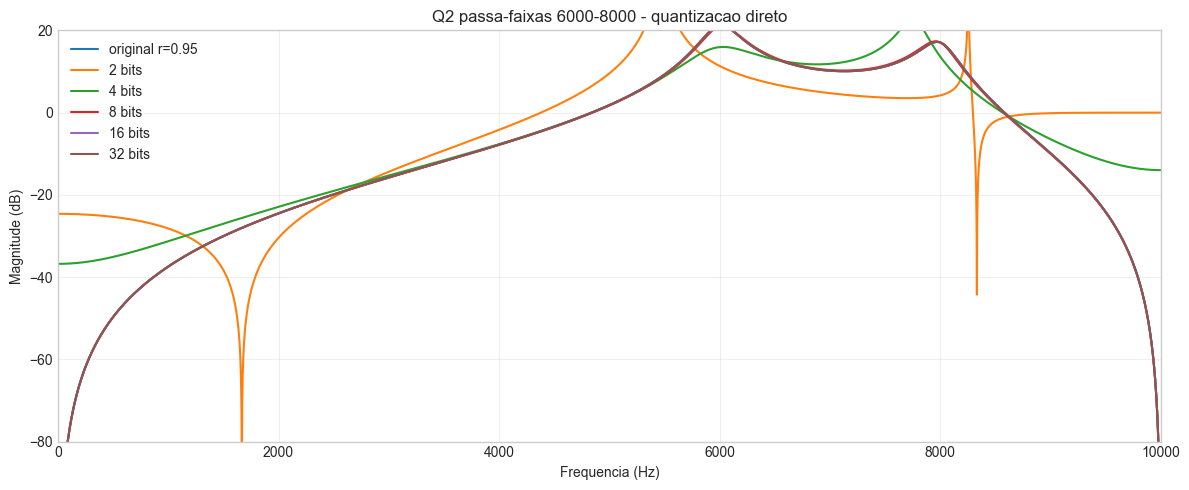

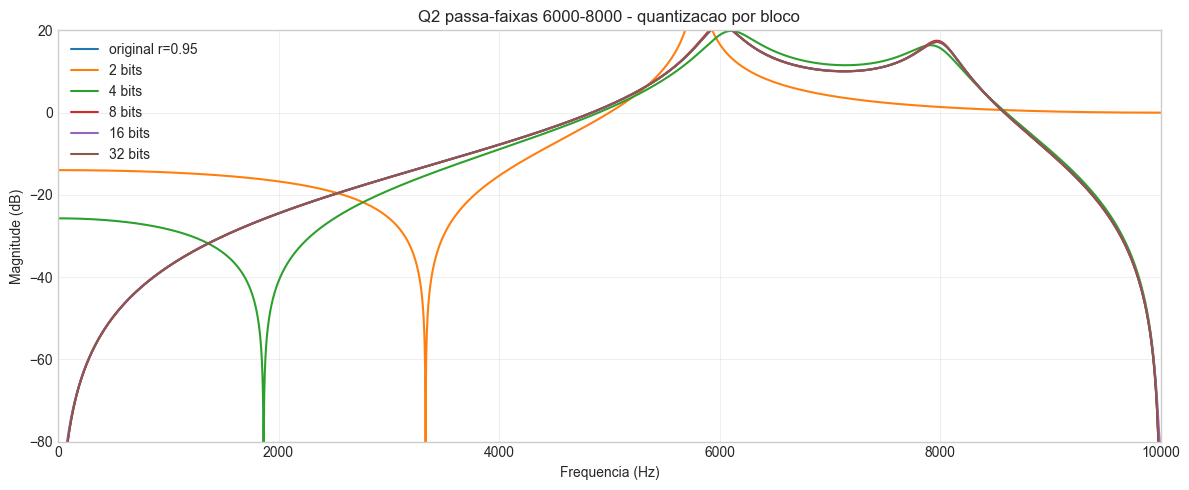

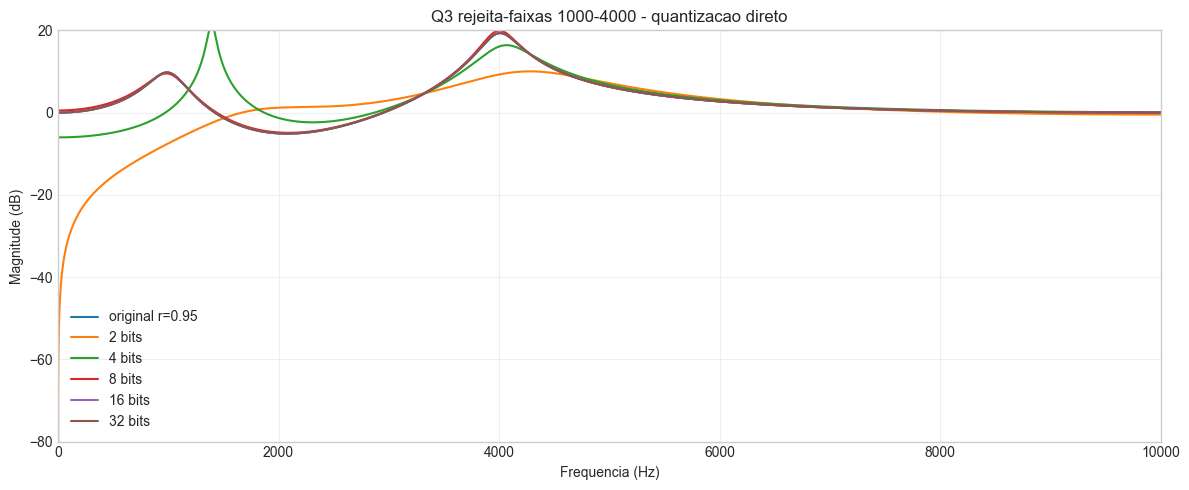

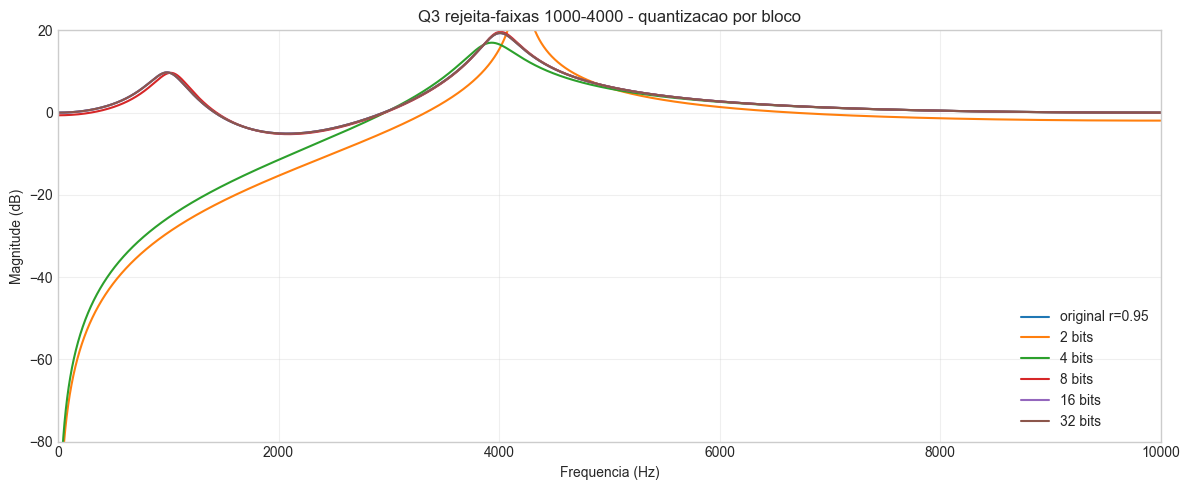

In [3]:

selected_r = 0.95

for project_name, (block_builder, mode, kind) in projects.items():
    blocks = block_builder(selected_r)
    original = compose_blocks(blocks, mode)
    for strategy, quantizer in [('direto', quantized_direct), ('por bloco', quantized_by_block)]:
        filters = {f'original r={selected_r}': original}
        for bits in BIT_VALUES:
            filters[f'{bits} bits'] = quantizer(blocks, mode, bits)
        plot_response_family(
            filters,
            f'{project_name} - quantizacao {strategy}',
            FS,
            xlim=(0, 10000),
        )


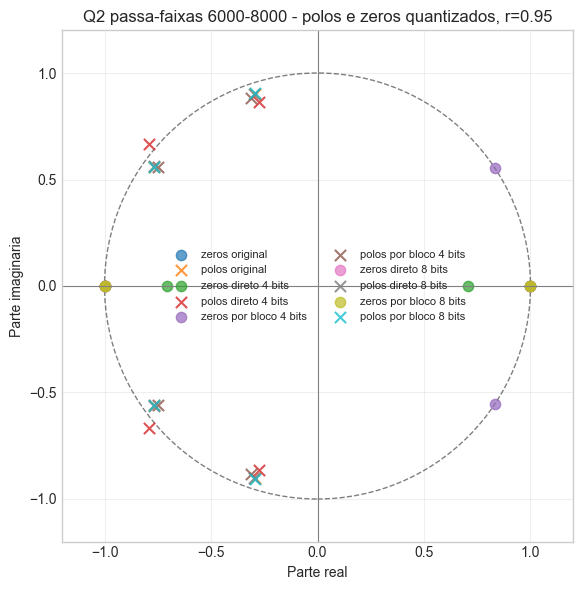

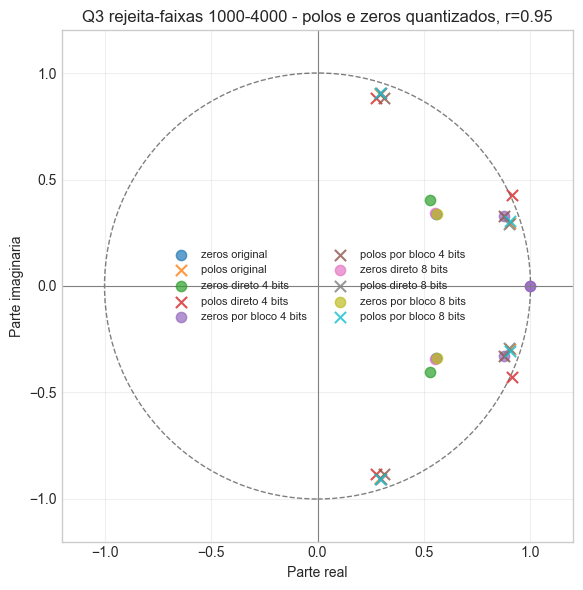

In [4]:

for project_name, (block_builder, mode, kind) in projects.items():
    blocks = block_builder(selected_r)
    original = compose_blocks(blocks, mode)
    filters = {'original': original}
    filters['direto 4 bits'] = quantized_direct(blocks, mode, 4)
    filters['por bloco 4 bits'] = quantized_by_block(blocks, mode, 4)
    filters['direto 8 bits'] = quantized_direct(blocks, mode, 8)
    filters['por bloco 8 bits'] = quantized_by_block(blocks, mode, 8)
    plot_pole_zero_family(filters, f'{project_name} - polos e zeros quantizados, r={selected_r}')


Conclusoes:

- Poucos bits deslocam polos e zeros de forma perceptivel e podem alterar bastante a resposta em frequencia.
- A quantizacao por bloco tende a ser mais controlada, porque cada secao de 2a ordem preserva melhor sua propria estrutura antes da composicao total.
- Quanto maior `r`, maior a seletividade e menor a folga numerica. Assim, os casos com `r = 0.98` sao os mais sensiveis a erros de quantizacao.